# Generating synthetic license plates with GAN

In [12]:
import hashlib
import urllib.request
from pathlib import Path

from tqdm import tqdm

UC3M_ZIP_URL = "https://edatos.consorciomadrono.es/api/access/datafile/12587"
UC3M_ZIP_MD5 = "496e3b5e66b78d231f71d85c0e5e11a3"


class Paths:
    def __init__(self, workdir: str = "./work", pretrain_synth_dir: str | None = None) -> None:
        self.work = Path(workdir).expanduser().resolve()
        self.cache = self.work / "cache"
        self.prepared = self.work / "data_prepared_uc3m"
        self.pretrain_synth = (
            Path(pretrain_synth_dir).expanduser().resolve()
            if pretrain_synth_dir
            else (self.work / "data_pretrain_synth")
        )
        self.models = self.work / "models"
        self.reports = self.work / "reports"

        for d in (self.work, self.cache, self.prepared, self.pretrain_synth, self.models, self.reports):
            d.mkdir(parents=True, exist_ok=True)

        self.uc3m_zip = self.cache / "UC3M-LP.zip"

        # inline MD5
        def file_md5(p: Path) -> str:
            h = hashlib.md5()
            with p.open("rb") as f:
                for chunk in iter(lambda: f.read(1024 * 1024), b""):
                    h.update(chunk)
            return h.hexdigest().lower()

        # ensure ZIP
        if self.uc3m_zip.exists() and file_md5(self.uc3m_zip) == UC3M_ZIP_MD5:
            print(f"[OK] ZIP already present + MD5 OK: {self.uc3m_zip}")
            return

        if self.uc3m_zip.exists():
            print("[WARN] ZIP present but MD5 mismatch. Re-downloading…")
            self.uc3m_zip.unlink(missing_ok=True)

        tmp = self.uc3m_zip.with_suffix(self.uc3m_zip.suffix + ".part")
        req = urllib.request.Request(UC3M_ZIP_URL, method="GET")

        with urllib.request.urlopen(req) as r, tmp.open("wb") as f:
            total = r.headers.get("Content-Length")
            with tqdm(
                total=int(total) if total else None,
                unit="B",
                unit_scale=True,
                unit_divisor=1024,
                desc=f"Downloading {self.uc3m_zip.name}",
            ) as pbar:
                for chunk in iter(lambda: r.read(1024 * 256), b""):
                    f.write(chunk)
                    pbar.update(len(chunk))

        tmp.replace(self.uc3m_zip)

        got = file_md5(self.uc3m_zip)
        if got != UC3M_ZIP_MD5:
            raise RuntimeError(f"MD5 mismatch: got={got} expected={UC3M_ZIP_MD5} file={self.uc3m_zip}")

        print(f"[OK] Downloaded + MD5 OK: {self.uc3m_zip}")

# usage
p = Paths("./work", "./work/pretrain_synth")
p.uc3m_zip


[OK] ZIP already present + MD5 OK: /content/work/cache/UC3M-LP.zip


PosixPath('/content/work/cache/UC3M-LP.zip')

# Training metrics configuration


In [13]:
from dataclasses import dataclass
from typing import Any, Dict, Optional


@dataclass(frozen=True, slots=True)
class StageCfg:
    epochs: int
    batch_size: int
    lr_g: float
    lr_d: float
    warmup_gan_epochs: int
    lambda_gan: float
    gan_ramp_epochs: int

    def as_dict(self) -> Dict[str, Any]:
        return {
            "epochs": self.epochs,
            "batch_size": self.batch_size,
            "lr_g": self.lr_g,
            "lr_d": self.lr_d,
            "warmup_gan_epochs": self.warmup_gan_epochs,
            "lambda_gan": self.lambda_gan,
            "gan_ramp_epochs": self.gan_ramp_epochs,
        }


class TrainCfg:
    __slots__ = (
        "do_pretrain",
        "do_finetune",
        "finetune_preset",
        "pretrain",
        "finetune",
        "lambda_l1",
        "lambda_edge",
        "quick_debug",
    )

    def __init__(
        self,
        *,
        do_pretrain: bool = True,
        do_finetune: bool = True,
        finetune_preset: str = "safe",
        pretrain: Optional[StageCfg] = None,
        finetune: Optional[StageCfg] = None,
        lambda_l1: float = 100.0,
        lambda_edge: float = 4.0,
        quick_debug: bool = False,
    ) -> None:
        self.do_pretrain = do_pretrain
        self.do_finetune = do_finetune
        self.finetune_preset = finetune_preset

        self.pretrain = pretrain or StageCfg(
            epochs=5,
            batch_size=2,
            lr_g=2e-5,
            lr_d=1e-5,
            warmup_gan_epochs=2,
            lambda_gan=0.3,
            gan_ramp_epochs=1,
        )

        self.finetune = finetune or StageCfg(
            epochs=12,
            batch_size=1,
            lr_g=1e-5,
            lr_d=2e-5,
            warmup_gan_epochs=2,
            lambda_gan=0.12,
            gan_ramp_epochs=2,
        )

        self.lambda_l1 = lambda_l1
        self.lambda_edge = lambda_edge
        self.quick_debug = quick_debug

    def as_dict(self) -> Dict[str, Any]:
        return {
            "do_pretrain": self.do_pretrain,
            "do_finetune": self.do_finetune,
            "finetune_preset": self.finetune_preset,
            "pretrain": self.pretrain.as_dict(),
            "finetune": self.finetune.as_dict(),
            "lambda_l1": self.lambda_l1,
            "lambda_edge": self.lambda_edge,
            "quick_debug": self.quick_debug,
        }


cfg = TrainCfg()
print(cfg.as_dict())


{'do_pretrain': True, 'do_finetune': True, 'finetune_preset': 'safe', 'pretrain': {'epochs': 5, 'batch_size': 2, 'lr_g': 2e-05, 'lr_d': 1e-05, 'warmup_gan_epochs': 2, 'lambda_gan': 0.3, 'gan_ramp_epochs': 1}, 'finetune': {'epochs': 12, 'batch_size': 1, 'lr_g': 1e-05, 'lr_d': 2e-05, 'warmup_gan_epochs': 2, 'lambda_gan': 0.12, 'gan_ramp_epochs': 2}, 'lambda_l1': 100.0, 'lambda_edge': 4.0, 'quick_debug': False}


# Dataset preparation
It consists of cropping plates from the original dataset and aligning them to the rectangular area.

In [14]:
# Prepare clean/real pairs from the UC3M-LP archive
import io
import json
import zipfile
import shutil
from typing import Tuple, List, Optional, Dict
import random
import csv
import numpy as np
from PIL import Image
from tqdm import tqdm

try:
    import cv2  # type: ignore
except Exception:
    cv2 = None

import re
from PIL import Image, ImageDraw, ImageFont

def normalize_text(s: str) -> str:
    """
    """Normalize plate text and guard against malformed meta.csv entries."""
    """
    if s is None:
        return ""
    s = str(s).upper().strip()
    s = re.sub(r"\s+", "", s)
    s = re.sub(r"[^A-Z0-9]", "", s)
    return s


def _pil_to_png_bytes(img: Image.Image) -> bytes:
    """Serialize a PIL image to PNG bytes without using a temporary file."""
    bio = io.BytesIO()
    img.save(bio, format="PNG", optimize=True)
    return bio.getvalue()

def render_clean_spanish_plate(text: str, w: int = 256, h: int = 64) -> Image.Image:
    text = normalize_text(text)

    NAVY = (10, 35, 90)
    WHITE = (245, 245, 245)
    BLACK = (10, 10, 10)
    BORDER = (25, 25, 25)

    img = Image.new("RGB", (w, h), WHITE)
    draw = ImageDraw.Draw(img)

    # border
    border = max(2, w // 128)
    draw.rectangle([0, 0, w - 1, h - 1], outline=BORDER, width=border)

    # EU band
    band_w = int(round(w * 0.16))
    draw.rectangle([0, 0, band_w, h], fill=NAVY)

    def pick_font(size: int) -> ImageFont.ImageFont:
        candidates = [
            # narrow/condensed first (often available on systems with DejaVu / Liberation fonts)
            "/usr/share/fonts/truetype/dejavu/DejaVuSansCondensed-Bold.ttf",
            "/usr/share/fonts/truetype/dejavu/DejaVuSansCondensed.ttf",
            "/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Bold.ttf",
            "/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Regular.ttf",
            # fallback
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
            "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        ]
        for fp in candidates:
            try:
                return ImageFont.truetype(fp, size=size)
            except Exception:
                pass
        return ImageFont.load_default()

    # add the country marker
    fontE = pick_font(size=int(h * 0.28))   # było ~0.40, teraz mniejsze
    e = "E"
    eb = draw.textbbox((0, 0), e, font=fontE)
    ew, eh = eb[2] - eb[0], eb[3] - eb[1]
    ex = (band_w - ew) // 2
    ey = (h - eh) // 2 + int(h * 0.2)                 # pionowo w środku paska
    draw.text((ex, ey), e, fill=WHITE, font=fontE)

    # space for the main text
    pad_x = int(round(w * 0.06))
    pad_y = int(round(h * 0.18))
    x0 = band_w + pad_x
    x1 = w - pad_x
    y0 = pad_y
    y1 = h - pad_y

    # choose a narrow font for the main text
    size = int(h * 0.70)
    font = pick_font(size=size)

    # fit height (stable vertical centering)
    max_h = (y1 - y0)
    while size > 10:
        font_try = pick_font(size=size)
        bb = draw.textbbox((0, 0), text, font=font_try)
        th = bb[3] - bb[1]
        if th <= max_h:
            font = font_try
            break
        size -= 1

    # compute per-char sizes for horizontal justification
    area_w = (x1 - x0)
    chars = list(text)
    if not chars:
        return img

    widths, heights = [], []
    for ch in chars:
        bb = draw.textbbox((0, 0), ch, font=font)
        widths.append(bb[2] - bb[0])
        heights.append(bb[3] - bb[1])

    text_w = sum(widths)
    text_h = max(heights) if heights else 0

    y_text = y0 + (max_h - text_h) // 2

    # if single char -> center both axes
    if len(chars) == 1:
        x_text = x0 + (area_w - widths[0]) // 2
        draw.text((x_text, y_text), chars[0], fill=BLACK, font=font)
        return img

    gaps = len(chars) - 1
    gap_space = area_w - text_w

    # if too wide, shrink the font until it fits
    while gap_space < 0 and size > 10:
        size -= 1
        font = pick_font(size=size)
        widths, heights = [], []
        for ch in chars:
            bb = draw.textbbox((0, 0), ch, font=font)
            widths.append(bb[2] - bb[0])
            heights.append(bb[3] - bb[1])
        text_w = sum(widths)
        text_h = max(heights) if heights else 0
        gap_space = area_w - text_w
        y_text = y0 + (max_h - text_h) // 2

    # justify horizontally across the available width
    gap = (gap_space / gaps) if gaps > 0 else 0.0

    x = float(x0)
    for i, ch in enumerate(chars):
        draw.text((int(round(x)), y_text), ch, fill=BLACK, font=font)
        x += widths[i]
        if i < gaps:
            x += gap

    return img



def normalize_plate_text(s: str) -> str:
    t = normalize_text(s)
    for i, ch in enumerate(t):
        if ch.isdigit():
            return t[i:]
    return t


def _extract_points_from_poly(poly) -> Tuple[List[float], List[float]]:
    xs: List[float] = []
    ys: List[float] = []
    if poly is None:
        return xs, ys
    if isinstance(poly, dict):
        if "points" in poly:
            return _extract_points_from_poly(poly.get("points"))
        if "x" in poly and "y" in poly and isinstance(poly["x"], list) and isinstance(poly["y"], list):
            try:
                for x, y in zip(poly["x"], poly["y"]):
                    xs.append(float(x)); ys.append(float(y))
                return xs, ys
            except Exception:
                return [], []
        for k in ("poly", "poly_coord", "coords", "coord"):
            if k in poly:
                return _extract_points_from_poly(poly.get(k))
        return [], []
    if isinstance(poly, list) and poly:
        if all(isinstance(p, (list, tuple)) and len(p) == 2 for p in poly):
            for p in poly:
                try:
                    xs.append(float(p[0])); ys.append(float(p[1]))
                except Exception:
                    pass
            return xs, ys
        try:
            vals = [float(v) for v in poly]
            for i in range(0, len(vals) - 1, 2):
                xs.append(vals[i]); ys.append(vals[i + 1])
            return xs, ys
        except Exception:
            return [], []
    return [], []


def _poly_to_bbox(xs: List[float], ys: List[float]) -> Optional[List[int]]:
    if not xs or not ys or len(xs) != len(ys):
        return None
    x1, y1, x2, y2 = min(xs), min(ys), max(xs), max(ys)
    if x2 <= x1 or y2 <= y1:
        return None
    return [int(x1), int(y1), int(x2), int(y2)]


def _bbox_to_xyxy(bbox: List[int], img_w: int, img_h: int) -> Optional[Tuple[int, int, int, int]]:
    if len(bbox) != 4:
        return None
    x1, y1, x2, y2 = bbox
    if x2 > 0 and y2 > 0 and (x1 + x2) <= img_w and (y1 + y2) <= img_h:
        x2 = x1 + x2
        y2 = y1 + y2
    if x2 <= x1 or y2 <= y1:
        return None
    x1 = max(0, min(img_w - 1, int(x1)))
    y1 = max(0, min(img_h - 1, int(y1)))
    x2 = max(1, min(img_w, int(x2)))
    y2 = max(1, min(img_h, int(y2)))
    if x2 <= x1 or y2 <= y1:
        return None
    return x1, y1, x2, y2


def _safe_open_image(b: bytes) -> Image.Image:
    return Image.open(io.BytesIO(b)).convert("RGB")


def _json_load(b: bytes):
    return json.loads(b.decode("utf-8", errors="replace"))


def order_points(pts: np.ndarray) -> np.ndarray:
    s = pts.sum(axis=1)
    d = (pts[:, 0] - pts[:, 1])
    tl = pts[np.argmin(s)]; br = pts[np.argmax(s)]; tr = pts[np.argmax(d)]; bl = pts[np.argmin(d)]
    return np.stack([tl, tr, br, bl], axis=0)


def warp_plate(pil_img: Image.Image, poly_pts: List[Tuple[float, float]], out_w: int, out_h: int) -> Optional[Image.Image]:
    if cv2 is None:
        return None
    try:
        pts = np.array(poly_pts, dtype=np.float32)
        if pts.shape[0] < 4:
            return None
        src = order_points(pts)
        dst = np.array([[0, 0], [out_w - 1, 0], [out_w - 1, out_h - 1], [0, out_h - 1]], dtype=np.float32)
        M = cv2.getPerspectiveTransform(src, dst)
        arr = np.array(pil_img.convert("RGB"))
        warped = cv2.warpPerspective(arr, M, (out_w, out_h), flags=cv2.INTER_CUBIC)
        return Image.fromarray(warped)
    except Exception:
        return None


def _find_single_char_anywhere(obj) -> Optional[str]:
    if obj is None:
        return None
    if isinstance(obj, str):
        c = normalize_text(obj.strip())
        return c if len(c) == 1 else None
    if isinstance(obj, (int, float)):
        try:
            n = int(obj)
            if 0 <= n <= 9:
                return str(n)
            if 10 <= n <= 35:
                return chr(ord("A") + (n - 10))
        except Exception:
            return None
    if isinstance(obj, dict):
        for k in ("char", "character", "value", "label", "text"):
            if k in obj:
                c = _find_single_char_anywhere(obj.get(k))
                if c:
                    return c
        for k in ("class", "cls", "id", "char_id", "label_id"):
            if k in obj:
                c = _find_single_char_anywhere(obj.get(k))
                if c:
                    return c
        for v in obj.values():
            c = _find_single_char_anywhere(v)
            if c:
                return c
    if isinstance(obj, list):
        for v in obj:
            c = _find_single_char_anywhere(v)
            if c:
                return c
    return None


def _char_center_x(ch: dict) -> Optional[float]:
    if not isinstance(ch, dict):
        return None
    for k in ("bbox", "box", "rect"):
        bb = ch.get(k)
        if isinstance(bb, (list, tuple)) and len(bb) == 4:
            try:
                x, y, a, b = [float(v) for v in bb]
                return x + a / 2.0
            except Exception:
                pass
    for k in ("poly_coord", "poly", "polygon", "points", "corners"):
        if k in ch:
            xs, ys = _extract_points_from_poly(ch.get(k))
            if xs:
                return float(min(xs) + (max(xs) - min(xs)) / 2.0)
    return None


def _chars_to_text(chars) -> str:
    if not isinstance(chars, list) or not chars:
        return ""
    seq: List[Tuple[float, str]] = []
    fallback: List[str] = []
    for ch in chars:
        c = _find_single_char_anywhere(ch)
        if c is None:
            continue
        cx = _char_center_x(ch) if isinstance(ch, dict) else None
        if cx is None:
            fallback.append(c)
        else:
            seq.append((cx, c))
    if seq:
        seq_sorted = sorted(seq, key=lambda t: t[0])
        return normalize_text("".join([c for _, c in seq_sorted]))
    return normalize_text("".join(fallback))


def _extract_plate_from_uc3m_json(j: object) -> Optional[Tuple[List[int], str, List[Tuple[float, float]]]]:
    if not isinstance(j, dict):
        return None
    lps = j.get("lps")
    if not isinstance(lps, list) or not lps:
        return None
    for lp in lps:
        if not isinstance(lp, dict):
            continue
        poly = lp.get("poly_coord")
        chars = lp.get("characters")
        lp_id = lp.get("lp_id") or lp.get("id") or lp.get("text")
        xs, ys = _extract_points_from_poly(poly)
        bbox_xyxy = _poly_to_bbox(xs, ys) if xs and ys else None
        if bbox_xyxy is None:
            continue
        text = lp_id if isinstance(lp_id, str) and len(lp_id) > 0 else _chars_to_text(chars)
        pts = [(float(x), float(y)) for x, y in zip(xs, ys)]
        return bbox_xyxy, text, pts
    return None


def prepare_paired_dataset_from_zip(
    zip_path: Path,
    out_dir: Path,
    plate_w: int,
    plate_h: int,
    *,
    max_train: Optional[int] = None,
    seed: int = 1337,
    min_ocr_len: int = 5,
) -> Dict[str, int]:
    rng = random.Random(int(seed))
    out_dir.mkdir(parents=True, exist_ok=True)
    # reset structure
    for split in ["train", "val", "test"]:
        for sub in ["clean", "real"]:
            d = out_dir / split / sub
            if d.exists():
                shutil.rmtree(d)
            d.mkdir(parents=True, exist_ok=True)
    meta_csv = out_dir / "meta.csv"
    if meta_csv.exists():
        meta_csv.unlink()

    stats = {"train": 0, "val": 0, "test": 0, "skipped": 0, "warped": 0, "bbox_fallback": 0}

    with zipfile.ZipFile(zip_path, "r") as zf:
        names = [n for n in zf.namelist() if not n.endswith("/")]
        img_exts = {".jpg", ".jpeg", ".png"}
        images: Dict[str, Dict[str, str]] = {"train": {}, "test": {}}
        jss: Dict[str, Dict[str, str]] = {"train": {}, "test": {}}

        def infer_split(p: str) -> Optional[str]:
            parts = [x.lower() for x in Path(p).parts]
            if "train" in parts:
                return "train"
            if "test" in parts:
                return "test"
            return None

        for n in names:
            split = infer_split(n)
            if split is None:
                continue
            p = Path(n)
            ext = p.suffix.lower()
            stem = p.stem
            if ext in img_exts:
                images[split].setdefault(stem, n)
            elif ext == ".json":
                jss[split].setdefault(stem, n)

        train_pairs = [(images["train"][s], jss["train"][s]) for s in sorted(set(images["train"]) & set(jss["train"]))]
        test_pairs = [(images["test"][s], jss["test"][s]) for s in sorted(set(images["test"]) & set(jss["test"]))]

        if not train_pairs or not test_pairs:
            raise RuntimeError("Brak par img/json w ZIP.")
        if max_train is not None:
            train_pairs = train_pairs[:max_train]
        rng.shuffle(train_pairs)
        val_n = max(1, int(0.10 * len(train_pairs)))
        val_pairs = train_pairs[:val_n]
        train_pairs = train_pairs[val_n:]

        def process(split: str, pairs: List[Tuple[str, str]]):
            for img_name, json_name in tqdm(pairs, desc=f"prepare:{split}", unit="img"):
                try:
                    img = _safe_open_image(zf.read(img_name))
                    j = _json_load(zf.read(json_name))
                    res = _extract_plate_from_uc3m_json(j)
                    if res is None:
                        stats["skipped"] += 1
                        continue
                    bbox, text, pts = res
                    xyxy = _bbox_to_xyxy(bbox, img.width, img.height)
                    if xyxy is None:
                        stats["skipped"] += 1
                        continue
                    x1, y1, x2, y2 = xyxy
                    real = None
                    if cv2 is not None and pts and len(pts) >= 4:
                        real = warp_plate(img, pts, plate_w, plate_h)
                        if real is not None:
                            stats["warped"] += 1
                    if real is None:
                        real = img.crop((x1, y1, x2, y2)).resize((plate_w, plate_h), Image.LANCZOS)
                        stats["bbox_fallback"] += 1
                    ntext = normalize_plate_text(text)
                    if len(ntext) < int(min_ocr_len):
                        stats["skipped"] += 1
                        continue
                    clean = render_clean_spanish_plate(ntext, w=plate_w, h=plate_h)
                    stem = Path(img_name).stem
                    (out_dir / split / "clean" / f"{stem}.png").write_bytes(_pil_to_png_bytes(clean))
                    (out_dir / split / "real" / f"{stem}.png").write_bytes(_pil_to_png_bytes(real))
                    with meta_csv.open("a", newline="", encoding="utf-8") as f:
                        w = csv.writer(f)
                        if f.tell() == 0:
                            w.writerow(["stem", "src_img", "src_json", "plate_text", "bbox_xyxy", "poly_pts"])
                        w.writerow([stem, img_name, json_name, ntext, json.dumps([x1, y1, x2, y2]), json.dumps(pts)])
                    stats[split] += 1
                except Exception:
                    stats["skipped"] += 1

        process("train", train_pairs)
        process("val", val_pairs)
        process("test", test_pairs)
    return stats

prepare_paired_dataset_from_zip(Path("./work/cache/UC3M-LP.zip"), Path("./work/data_prepared_uc3m"), 256, 64, seed=1337, min_ocr_len=5)

prepare:test: 100%|██████████| 395/395 [02:13<00:00,  2.95img/s]


{'train': 1369,
 'val': 156,
 'test': 376,
 'skipped': 74,
 'warped': 1975,
 'bbox_fallback': 0}

# Generating pseudo license plates
These plates are generated from sketches and then processed with operations such as rotation and noise to make them more realistic. They are still synthetic plates.

In [15]:
try:
    import cv2  # type: ignore
except Exception:
    %pip -q install opencv-python
    import cv2  # type: ignore

import math
import random
from pathlib import Path

import numpy as np
from PIL import Image
from tqdm import tqdm

# ----------------------------
# PATHS
# ----------------------------
ROOT = Path("./work/data_prepared_uc3m").resolve()
SPLITS = ["train", "val", "test"]

IN_CLEAN = "clean"
IN_REAL  = "real"     # optional reference real images for texture mixing
OUT_PSEUDO = "pseudo"

SEED = 1337
MAX_PER_SPLIT = None      # e.g. 2000 for a test run
COPIES_PER_IMAGE = 1      # e.g. 2-4 to generate more variants per clean image

rng = random.Random(SEED)

# ----------------------------
# helpers
# ----------------------------
def pil_to_bgr(pil: Image.Image) -> np.ndarray:
    arr = np.array(pil.convert("RGB"))
    return cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)

def bgr_to_pil(bgr: np.ndarray) -> Image.Image:
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return Image.fromarray(rgb)

def randf(a: float, b: float) -> float:
    return a + (b - a) * rng.random()

def randi(a: int, b: int) -> int:
    return rng.randint(a, b)

def clamp_u8(x: np.ndarray) -> np.ndarray:
    return np.clip(x, 0, 255).astype(np.uint8)

# ----------------------------
# augmentations
# ----------------------------
def random_perspective(bgr: np.ndarray) -> np.ndarray:
    h, w = bgr.shape[:2]
    mx = int(w * randf(0.02, 0.08))
    my = int(h * randf(0.04, 0.18))

    src = np.float32([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]])
    dst = np.float32([
        [randi(0, mx),             randi(0, my)],
        [w - 1 - randi(0, mx),     randi(0, my)],
        [w - 1 - randi(0, mx),     h - 1 - randi(0, my)],
        [randi(0, mx),             h - 1 - randi(0, my)],
    ])

    if rng.random() < 0.35:
        k = randi(0, 3)
        dst[k, 0] += randi(-mx, mx)
        dst[k, 1] += randi(-my, my)

    M = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(bgr, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

def random_rotate_scale(bgr: np.ndarray) -> np.ndarray:
    h, w = bgr.shape[:2]
    ang = randf(-6.0, 6.0)
    sc  = randf(0.92, 1.06)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), ang, sc)
    return cv2.warpAffine(bgr, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

def random_brightness_contrast(bgr: np.ndarray) -> np.ndarray:
    alpha = randf(0.80, 1.20)
    beta  = randf(-18, 18)
    return cv2.convertScaleAbs(bgr, alpha=alpha, beta=beta)

def slight_color_cast(bgr: np.ndarray) -> np.ndarray:
    if rng.random() < 0.45:
        cast = np.array([randf(0.95, 1.05), randf(0.95, 1.05), randf(0.95, 1.05)], dtype=np.float32)
        return clamp_u8(bgr.astype(np.float32) * cast[None, None, :])
    return bgr

def add_gaussian_noise(bgr: np.ndarray) -> np.ndarray:
    if rng.random() < 0.70:
        sigma = randf(3.0, 12.0)
        noise = np.random.normal(0.0, sigma, bgr.shape).astype(np.float32)
        return clamp_u8(bgr.astype(np.float32) + noise)
    return bgr

def gaussian_blur(bgr: np.ndarray) -> np.ndarray:
    if rng.random() < 0.55:
        k = rng.choice([3, 5, 7])
        return cv2.GaussianBlur(bgr, (k, k), sigmaX=randf(0.2, 1.2))
    return bgr

def motion_blur(bgr: np.ndarray) -> np.ndarray:
    if rng.random() < 0.35:
        k = randi(5, 17)
        ang = randf(0.0, math.pi)
        kernel = np.zeros((k, k), dtype=np.float32)
        cx = cy = k // 2
        for i in range(k):
            x = int(round(cx + (i - cx) * math.cos(ang)))
            y = int(round(cy + (i - cy) * math.sin(ang)))
            if 0 <= x < k and 0 <= y < k:
                kernel[y, x] = 1.0
        kernel /= max(kernel.sum(), 1e-6)
        return cv2.filter2D(bgr, -1, kernel)
    return bgr

def vignette(bgr: np.ndarray) -> np.ndarray:
    if rng.random() < 0.35:
        h, w = bgr.shape[:2]
        x = cv2.getGaussianKernel(w, w * randf(0.25, 0.55))
        y = cv2.getGaussianKernel(h, h * randf(0.25, 0.55))
        mask = (y @ x.T)
        mask = mask / mask.max()
        strength = randf(0.25, 0.55)
        mask = (1.0 - strength) + strength * mask
        return clamp_u8(bgr.astype(np.float32) * mask[..., None])
    return bgr

def jpeg_artifacts(bgr: np.ndarray) -> np.ndarray:
    if rng.random() < 0.55:
        q = randi(35, 85)
        ok, enc = cv2.imencode(".jpg", bgr, [int(cv2.IMWRITE_JPEG_QUALITY), q])
        if ok:
            return cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return bgr

def augment_clean_to_pseudo_real(clean_pil: Image.Image, ref_real_pil: Image.Image | None = None) -> Image.Image:
    clean = pil_to_bgr(clean_pil)

    # optional real-texture mix if real images are available in prepared_uc3m
    if ref_real_pil is not None and rng.random() < 0.60:
        real = pil_to_bgr(ref_real_pil)
        a = randf(0.75, 0.92)  # clean dominuje (czytelność)
        clean = cv2.addWeighted(clean, a, real, 1.0 - a, 0.0)

    # geometry
    clean = random_perspective(clean)
    clean = random_rotate_scale(clean)

    # photometry + degradations
    clean = random_brightness_contrast(clean)
    clean = slight_color_cast(clean)
    clean = add_gaussian_noise(clean)
    clean = gaussian_blur(clean)
    clean = motion_blur(clean)
    clean = vignette(clean)
    clean = jpeg_artifacts(clean)

    return bgr_to_pil(clean)

total = 0
for sp in SPLITS:
    d_clean = ROOT / sp / IN_CLEAN
    d_real  = ROOT / sp / IN_REAL
    if not d_clean.exists():
        print(f"[SKIP] brak: {d_clean}")
        continue

    d_pseudo = ROOT / sp / OUT_PSEUDO
    d_pseudo.mkdir(parents=True, exist_ok=True)

    files = sorted([*d_clean.glob("*.png"), *d_clean.glob("*.jpg"), *d_clean.glob("*.jpeg")])
    if MAX_PER_SPLIT is not None:
        files = files[:MAX_PER_SPLIT]

    for p in tqdm(files, desc=f"pseudo:{sp}", unit="img"):
        clean_pil = Image.open(p).convert("RGB")

        # match real images by stem if available
        ref_real = None
        if d_real.exists():
            cand = d_real / (p.stem + ".png")
            if not cand.exists():
                for ext in [".jpg", ".jpeg", ".png"]:
                    c2 = d_real / (p.stem + ext)
                    if c2.exists():
                        cand = c2
                        break
            if cand.exists():
                ref_real = Image.open(cand).convert("RGB")

        # save pseudo samples (you can generate multiple versions per image)
        for k in range(int(COPIES_PER_IMAGE)):
            suffix = "" if COPIES_PER_IMAGE == 1 else f"__aug{k:02d}"
            out_path = d_pseudo / (p.stem + suffix + ".png")
            pseudo = augment_clean_to_pseudo_real(clean_pil, ref_real)
            pseudo.save(out_path, format="PNG", optimize=True)

        total += 1

print(f"OK: generated pseudo data for {total} files to: {ROOT}/<split>/{OUT_PSEUDO}")


# Model definition


In [16]:
# model Pix2Pix: U-Net generator + PatchGAN discriminator for plates.

from typing import Optional

import torch
import torch.nn as nn


# Weight initialization - standard for GANs
# Typical GAN initialization uses mean 0 and std 0.02
def init_weights(m: nn.Module) -> None:
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)): # Sprawdza czy dobry typ, tzw dobra praktyka
        nn.init.normal_(m.weight, 0.0, 0.02)    # wagi bliskie zeru stablizują trening na początku
        if m.bias is not None:
            nn.init.zeros_(m.bias)

    if isinstance(m, (nn.BatchNorm2d, nn.InstanceNorm2d)):   # Sprawdza czy dobry typ, tzw dobra praktyka
        if getattr(m, "weight", None) is not None:
            nn.init.normal_(m.weight, 1.0, 0.02)
        if getattr(m, "bias", None) is not None:
            nn.init.zeros_(m.bias)


# U-Net blocks
class UNetDown(nn.Module):
    # Conv -> (Norm) -> LeakyReLU (+ Dropout)
    # If normalize=False, normalization is skipped
    def __init__(self, in_ch: int, out_ch: int, normalize: bool = True, dropout: float = 0.0):
        super().__init__()
        # bias is unnecessary because normalization follows
        self.conv = nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False)   # kernel 4, stride 2 = zmniejsza H,W o połowę

        self.use_norm = normalize
        if self.use_norm:
            self.norm = nn.InstanceNorm2d(out_ch)   # stabilizuje aktywacje, działa dobrze przy małych batchach

        self.act = nn.LeakyReLU(0.2, inplace=True)

        self.use_dropout = dropout > 0.0
        if self.use_dropout:
            self.drop = nn.Dropout(dropout)
    # Order: conv -> (norm) -> activation -> (dropout)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        if self.use_norm:
            x = self.norm(x)
        x = self.act(x)
        if self.use_dropout:
            x = self.drop(x)
        return x


class UNetUp(nn.Module):
    # Deconv -> Norm -> ReLU (+ Dropout) -> concatenate with skip
    # If skip is None, no concatenation is performed
    def __init__(self, in_ch: int, out_ch: int, dropout: float = 0.0):
        super().__init__()

        self.deconv = nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False)    #podwaja H,W (upsampling)
        self.norm = nn.InstanceNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)

        self.use_dropout = dropout > 0.0
        if self.use_dropout:
            self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, skip: Optional[torch.Tensor]) -> torch.Tensor:
        x = self.deconv(x)
        x = self.norm(x)
        x = self.act(x)
        if self.use_dropout:
            x = self.drop(x)

        if skip is not None:
            x = torch.cat([x, skip], dim=1)

        return x


# Generator: U-Net (pix2pix)
class GeneratorUNet(nn.Module):
    def __init__(self, in_channels: int = 3, out_channels: int = 3, up_dropout: float = 0.0):
        super().__init__()

        # Encoder (downsampling)
        self.d1 = UNetDown(in_channels, 64, normalize=False)
        self.d2 = UNetDown(64, 128)
        self.d3 = UNetDown(128, 256)
        self.d4 = UNetDown(256, 512)
        self.d5 = UNetDown(512, 512)

        # Decoder (upsampling)
        # Note: input channel counts match the skip concatenations
        self.u1 = UNetUp(512, 512, dropout=up_dropout)   # + skip d4 => 1024
        self.u2 = UNetUp(1024, 512, dropout=up_dropout)  # + skip d3 => 768
        self.u3 = UNetUp(768, 256, dropout=up_dropout)   # + skip d2 => 384
        self.u4 = UNetUp(384, 128)                       # + skip d1 => 192
        self.u5 = UNetUp(192, 64)                        # bez skipa

        # Output
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=3, stride=1, padding=1)
        self.final_act = nn.Tanh()

        self.apply(init_weights)

    def forward(self, clean: torch.Tensor) -> torch.Tensor:
        # Downsampling path
        x1 = self.d1(clean)
        x2 = self.d2(x1)
        x3 = self.d3(x2)
        x4 = self.d4(x3)
        x5 = self.d5(x4)

        # Upsampling path with skips
        y1 = self.u1(x5, x4)
        y2 = self.u2(y1, x3)
        y3 = self.u3(y2, x2)
        y4 = self.u4(y3, x1)
        y5 = self.u5(y4, None)

        # Final layer
        out = self.final_conv(y5)
        out = self.final_act(out)
        return out


# Discriminator: PatchGAN
class DiscriminatorPatchGAN(nn.Module):
    def __init__(self, in_channels: int = 3, base: int = 64):
        super().__init__()

        # On input we concatenate clean and real/fake along channels: 3 + 3 = 6
        c = in_channels * 2

        # First block without normalization
        self.conv1 = nn.Conv2d(c, base, 4, 2, 1, bias=False)
        self.act1 = nn.LeakyReLU(0.2, inplace=True)

        # Subsequent blocks use InstanceNorm and progressively downsample
        # Block 2: halves the resolution and doubles the channels
        # kernel=4, stride=2, padding=1 -> standard PatchGAN downsampling
        self.conv2 = nn.Conv2d(base, base * 2, 4, 2, 1, bias=False)   # bias=False, bo po conv i tak jest normalizacja
        self.norm2 = nn.InstanceNorm2d(base * 2)                     # stabilizuje aktywacje, działa dobrze przy małych batchach
        self.act2 = nn.LeakyReLU(0.2, inplace=True)                  # nie zeruje gradientu dla ujemnych wartości

        # Block 3: another 2x downsampling and more channels
        self.conv3 = nn.Conv2d(base * 2, base * 4, 4, 2, 1, bias=False)  # coraz więcej cech, coraz mniejsza mapa
        self.norm3 = nn.InstanceNorm2d(base * 4)                         # normalizacja per kanał / per próbka
        self.act3 = nn.LeakyReLU(0.2, inplace=True)                      # standardowa aktywacja w dyskryminatorach GAN

        # Block 4: deeper features, still downsampling
        self.conv4 = nn.Conv2d(base * 4, base * 8, 4, 2, 1, bias=False)  # robi bardziej "abstrakcyjne" cechy
        self.norm4 = nn.InstanceNorm2d(base * 8)                         # utrzymuje stabilny rozkład aktywacji
        self.act4 = nn.LeakyReLU(0.2, inplace=True)                      # pomaga w uczeniu zamiast ReLU w D


        # Final layer outputs a probability map (patches)
        self.conv_out = nn.Conv2d(base * 8, 1, 4, 1, 1)

        self.apply(init_weights)

    def forward(self, clean: torch.Tensor, real_or_fake: torch.Tensor) -> torch.Tensor:
        # clean and real_or_fake have shape [B, C, H, W]
        # concatenating channels creates the conditional input [B, 2C, H, W]
        x = torch.cat([clean, real_or_fake], dim=1)

        # Block 1: conv + LeakyReLU
        # conv reduces resolution (stride=2), and LeakyReLU keeps gradients for negatives
        x = self.conv1(x)
        x = self.act1(x)

        # Block 2: conv + norm + LeakyReLU
        # conv further reduces H,W and increases channels; norm stabilizes activations
        x = self.conv2(x)
        x = self.norm2(x)
        x = self.act2(x)

        # Block 3: deeper features, smaller map, more channels
        x = self.conv3(x)
        x = self.norm3(x)
        x = self.act3(x)

        # Block 4: even higher-level features, still downsampling
        x = self.conv4(x)
        x = self.norm4(x)
        x = self.act4(x)

        # PatchGAN output: map [B, 1, H', W']
        # each point in the map scores one image patch
        x = self.conv_out(x)
        return x



# Quick test: builds the models and counts parameters
G = GeneratorUNet()
D = DiscriminatorPatchGAN()

print("Generator:", sum(p.numel() for p in G.parameters()) / 1e6, "M params")
print("Discriminator:", sum(p.numel() for p in D.parameters()) / 1e6, "M params")


Generator: 23.663299 M params
Discriminator: 2.766849 M params


# Shared training components


In [17]:
# Wspólne elementy dla treningu Pix2Pix (dane, loadery, straty, rampy): pretrain + finetune

import random
from pathlib import Path
from typing import List, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm


WORK = Path("./work").resolve()
ROOT = WORK / "data_prepared_uc3m"

PLATE_H = 64
PLATE_W = 256
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _set_seed_from_cfg(cfg) -> int:
    seed = int(getattr(cfg, "seed", 1337))
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    return seed

SEED = _set_seed_from_cfg(cfg)




def pil_to_tensor(pil: Image.Image) -> torch.Tensor:
    import numpy as np
    arr = (np.array(pil.convert("RGB")).astype("float32") / 255.0)
    t = torch.from_numpy(arr).permute(2, 0, 1)  # [3,H,W]
    return t * 2.0 - 1.0  # [-1,1]

def _glob_images(d: Path) -> List[Path]:
    exts = ("*.png", "*.jpg", "*.jpeg")
    out: List[Path] = []
    for e in exts:
        out.extend(d.glob(e))
    return out

# Tworzy Dataset par clean/target
class CleanTargetPairs(Dataset):
    def __init__(self, root: Path, split: str, target_name: str):
        self.clean_dir = root / split / "clean"
        self.target_dir = root / split / target_name

        if not self.clean_dir.exists():
            raise RuntimeError(f"Brak: {self.clean_dir}")
        if not self.target_dir.exists():
            raise RuntimeError(f"Brak: {self.target_dir} (przygotuj dane: {target_name})")

        clean = {}
        for p in _glob_images(self.clean_dir):
            clean[p.stem] = p

        target = {}
        for p in _glob_images(self.target_dir):
            target[p.stem] = p
        # Stem czyli nazwa pliku bez rozszerzenia
        # target to np. "real" albo "pseudo"
        stems = sorted(set(clean) & set(target))
        if not stems:
            raise RuntimeError(f"Brak wspólnych stemów clean/{target_name} dla split={split}")

        self.items: List[Tuple[str, Path, Path]] = [(st, clean[st], target[st]) for st in stems]

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, i: int):
        stem, p_clean, p_target = self.items[i]
        clean = pil_to_tensor(Image.open(p_clean).resize((PLATE_W, PLATE_H), Image.BICUBIC))
        target = pil_to_tensor(Image.open(p_target).resize((PLATE_W, PLATE_H), Image.BICUBIC))
        return clean, target, stem


def make_loaders(target_name: str, cfg_section, root: Path = ROOT) -> Tuple[DataLoader, Optional[DataLoader]]:
    bs = int(getattr(cfg_section, "batch_size", 4))
    nw = int(getattr(cfg_section, "num_workers", 2))

    train_ds = CleanTargetPairs(root, "train", target_name)
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=nw, pin_memory=True)

    val_loader: Optional[DataLoader] = None
    if (root / "val" / "clean").exists() and (root / "val" / target_name).exists():
        val_ds = CleanTargetPairs(root, "val", target_name)
        val_loader = DataLoader(
            val_ds, batch_size=1, shuffle=False, num_workers=nw, pin_memory=True
        )
    return train_loader, val_loader

# bce to skrót od Binary Cross Entropy - funkcji straty do klasyfikacji binarnej.
bce = nn.BCEWithLogitsLoss()

def d_loss(d_real: torch.Tensor, d_fake: torch.Tensor) -> torch.Tensor:
    return 0.5 * (
        bce(d_real, torch.ones_like(d_real)) +
        bce(d_fake, torch.zeros_like(d_fake))
    )

def g_gan_loss(d_fake: torch.Tensor) -> torch.Tensor:
    return bce(d_fake, torch.ones_like(d_fake))
# Ta funkcja wylicza aktualną wagę straty GAN (lambda_gan) dla danej epoki, tak żeby GAN był włączany stopniowo.
def lambda_gan_epoch_cfg(epoch_1based: int, cfg_section) -> float:
    warm = int(getattr(cfg_section, "warmup_gan_epochs", 0))
    lam = float(getattr(cfg_section, "lambda_gan", 1.0))
    ramp_epochs = max(1, int(getattr(cfg_section, "gan_ramp_epochs", 1)))

    if epoch_1based <= warm:
        return 0.0

    start = warm + 1
    t = (epoch_1based - start + 1) / float(ramp_epochs)
    t = max(0.0, min(1.0, t))
    return lam * t


def train_one_epoch_pix2pix(
    G, D,
    train_loader: DataLoader,
    optG, optD,
    lambda_l1: float,
    lam_gan: float,
    device: torch.device = DEVICE,
    desc: str = "train"
) -> dict:
    G.train(); D.train()                         # tryb treningowy dla obu modeli
    gan_on = lam_gan > 0.0                       # jeśli lam_gan=0, to trenujemy tylko L1 bez GAN

    pbar = tqdm(train_loader, desc=desc, unit="batch")  # pasek postępu po batchach
    last = {"lossG": None, "lossD": None, "l1": None, "gan": None, "gan_on": int(gan_on)}  # ostatnie straty do logowania

    for clean, target, _stem in pbar:
        clean = clean.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        # forward generatora: tworzy fake na podstawie clean
        fake = G(clean)

        lossD = torch.tensor(0.0, device=device) # domyślnie 0, gdy gan_off
        if gan_on:
            optD.zero_grad(set_to_none=True) # zerowanie gradientów D

            d_real = D(clean, target) # D widzi parę (clean, target) jako real
            d_fake = D(clean, fake.detach()) # D widzi parę (clean, fake) jako fake
                                            # detach: nie liczymy gradientu do G w kroku D

            lossD = d_loss(d_real, d_fake)  # BCE dla real=1 i fake=0

            if torch.isfinite(lossD): # ochrona przed NaN/Inf
                lossD.backward()
                optD.step()

        # krok G (generator)
        optG.zero_grad(set_to_none=True)          # zerowanie gradientów G

        # L1: generator ma odtwarzać target piksel po pikselu
        loss_l1 = F.l1_loss(fake, target) * lambda_l1

        loss_gan = torch.tensor(0.0, device=device)   # domyślnie 0, gdy gan_off
        if gan_on:
            d_fake_for_g = D(clean, fake)             # teraz bez detach, bo gradient do G
            loss_gan = g_gan_loss(d_fake_for_g) * lam_gan  # G chce, żeby D zwrócił "real dla fake

        # całkowita strata generatora
        lossG = loss_l1 + loss_gan

        if torch.isfinite(lossG):         # ochrona przed NaN/Inf
            lossG.backward()
            optG.step()

        # zapis ostatnich wartości do wyświetlenia w tqdm
        last = {
            "lossG": float(lossG.detach().cpu()),
            "lossD": float(lossD.detach().cpu()),
            "l1": float(loss_l1.detach().cpu()),
            "gan": float(loss_gan.detach().cpu()),
            "gan_on": int(gan_on),
        }
        pbar.set_postfix(**last)

    return last                                   # zwraca straty z ostatniego batcha w epoce


@torch.no_grad()   # wyłącza liczenie gradientów, bo to tylko ewaluacja
def eval_mean_l1(G, val_loader: Optional[DataLoader], device: torch.device = DEVICE) -> Optional[float]:
    if val_loader is None:
        return None
    G.eval()                                    # tryb ewaluacji (dropout off, normy w trybie inference)
    s, n = 0.0, 0                               # suma błędu L1 i licznik próbek

    for clean, target, _stem in val_loader:
        clean = clean.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        fake = G(clean)                         # generator tworzy obraz wyjściowy

        # liczy błąd L1 dla jednej próbki i dodaje do sumy
        s += float(F.l1_loss(fake, target).detach().cpu())
        n += 1                                 # zlicza liczbę próbek

    # średni błąd L1 po całym zbiorze walidacyjnym
    return s / max(1, n)



# Pretraining


In [18]:
# PRETRAIN
# Pretrening na pseudo-realnych danych (augmentowanych), żeby ustabilizować G/D.
OUTDIR = WORK / "models" / "pretrain_pix2pix"
OUTDIR.mkdir(parents=True, exist_ok=True)

train_loader, val_loader = make_loaders("pseudo", cfg.pretrain)

G = G.to(DEVICE)
D = D.to(DEVICE)

optG = torch.optim.Adam(G.parameters(),lr=float(getattr(cfg.pretrain, "lr_g", 2e-4)),betas=(0.5, 0.999))
optD = torch.optim.Adam(D.parameters(),lr=float(getattr(cfg.pretrain, "lr_d", 2e-4)),betas=(0.5, 0.999))

lambda_l1 = float(getattr(cfg, "lambda_l1", getattr(cfg.pretrain, "lambda_l1", 100.0)))

best_val = float("inf")
global_step = 0
epochs = int(getattr(cfg.pretrain, "epochs", 5))
if True:
    for epoch in range(1, epochs + 1):
        lam_gan = lambda_gan_epoch_cfg(epoch, cfg.pretrain)

        train_one_epoch_pix2pix(
            G, D,
            train_loader,
            optG, optD,
            lambda_l1=lambda_l1,
            lam_gan=lam_gan,
            device=DEVICE,
            desc=f"pretrain e{epoch}/{epochs} gan={lam_gan:.4f}",
        )

        global_step += len(train_loader)

        val_l1 = eval_mean_l1(G, val_loader, DEVICE)

        ckpt = {
            "epoch": epoch,
            "global_step": global_step,
            "cfg": cfg.as_dict() if hasattr(cfg, "as_dict") else None,
            "G_state": G.state_dict(),
            "D_state": D.state_dict(),
            "optG": optG.state_dict(),
            "optD": optD.state_dict(),
            "val_l1": val_l1,
            "lambda_l1": lambda_l1,
            "lambda_gan": lam_gan,
        }

        p = OUTDIR / f"pretrain_epoch{epoch:03d}.pt"
        torch.save(ckpt, p)

        if (lam_gan > 0.0) and (val_l1 is not None) and (val_l1 < best_val):
            best_val = val_l1
            torch.save(ckpt, OUTDIR / "pretrain_best.pt")

        print(f"[E{epoch}] saved={p.name} val_l1={val_l1} best_val={best_val}")

    print("DONE. Checkpoints in:", OUTDIR)


# Fine-tuning


In [19]:
# FINETUNE
# Fine-tuning on real plates, initializing from pretrain_best.pt if available.


# paths
PRETRAIN_DIR = WORK / "models" / "pretrain_pix2pix"
OUTDIR = WORK / "models" / "finetune_pix2pix"
OUTDIR.mkdir(parents=True, exist_ok=True)

train_loader, val_loader = make_loaders("real", cfg.finetune)

G = G.to(DEVICE)
D = D.to(DEVICE)

# initialize from pretrain_best.pt if it exists
pre_best = PRETRAIN_DIR / "pretrain_best.pt"

ck = None
g_state = None
d_state = None
if True:
    if pre_best.exists():
        ck = torch.load(pre_best, map_location="cpu")
        g_state = ck.get("G_state")
        d_state = ck.get("D_state")
        print(f"[INIT] found {pre_best}")
    else:
        print(f"[INIT] pretrain_best.pt not found under {PRETRAIN_DIR} -> start from current weights")

    # check whether this is a UNet without any() or generators
    has_d1 = False
    has_u1 = False
    has_final = False

    if isinstance(g_state, dict):
        keys_list = list(g_state.keys())

        i = 0
        while i < len(keys_list):
            k = keys_list[i]

            if (not has_d1) and k.startswith("d1."):
                has_d1 = True

            if (not has_u1) and k.startswith("u1."):
                has_u1 = True

            if (not has_final) and k.startswith("final_conv."):
                has_final = True

            # stop once everything has been found
            if has_d1 and has_u1 and has_final:
                break

            i += 1

    is_unet = has_d1 and has_u1 and has_final

    # load generator
    if pre_best.exists() and isinstance(g_state, dict) and is_unet:
        G.load_state_dict(g_state, strict=True)
        print("[INIT] loaded G (UNet) from pretrain_best.pt")
    elif pre_best.exists():
        print("[INIT] skip G init (no G_state dict or not UNet-like)")

    # load discriminator
    if pre_best.exists() and isinstance(d_state, dict):
        try:
            D.load_state_dict(d_state, strict=True)
            print("[INIT] loaded D from pretrain_best.pt (strict=True)")
        except Exception:
            missing, unexpected = D.load_state_dict(d_state, strict=False)
            if (len(missing) == 0) and (len(unexpected) == 0):
                print("[INIT] loaded D from pretrain_best.pt (strict=False, but compatible)")
            else:
                print(f"[INIT] skip D init (incompatible) missing={len(missing)} unexpected={len(unexpected)}")
    elif pre_best.exists():
        print("[INIT] skip D init (no D_state dict)")

    optG = torch.optim.Adam(G.parameters(),lr=float(getattr(cfg.finetune, "lr_g", 2e-4)),betas=(0.5, 0.999))
    optD = torch.optim.Adam(D.parameters(),lr=float(getattr(cfg.finetune, "lr_d", 2e-4)),betas=(0.5, 0.999))

    # L1 coefficient
    lambda_l1 = float(getattr(cfg, "lambda_l1", getattr(cfg.finetune, "lambda_l1", 100.0)))

    # training loop
    best_val = float("inf")
    global_step = 0
    epochs = int(getattr(cfg.finetune, "epochs", 10))

    for epoch in range(1, epochs + 1):
        lam_gan = lambda_gan_epoch_cfg(epoch, cfg.finetune)

        train_one_epoch_pix2pix(G, D,train_loader,optG, optD,lambda_l1=lambda_l1,lam_gan=lam_gan,device=DEVICE,desc=f"finetune e{epoch}/{epochs} gan={lam_gan:.4f}")

        global_step += len(train_loader)

        val_l1 = eval_mean_l1(G, val_loader, DEVICE)

        ckpt = {
            "epoch": epoch,
            "global_step": global_step,
            "cfg": cfg.as_dict() if hasattr(cfg, "as_dict") else None,
            "G_state": G.state_dict(),
            "D_state": D.state_dict(),
            "optG": optG.state_dict(),
            "optD": optD.state_dict(),
            "val_l1": val_l1,
            "lambda_l1": lambda_l1,
            "lambda_gan": lam_gan,
        }

        p = OUTDIR / f"finetune_epoch{epoch:03d}.pt"
        torch.save(ckpt, p)

        if (lam_gan > 0.0) and (val_l1 is not None) and (val_l1 < best_val):
            best_val = val_l1
            torch.save(ckpt, OUTDIR / "finetune_best.pt")

        print(f"[E{epoch}] saved={p.name} val_l1={val_l1} best_val={best_val}")

    print("DONE. Checkpoints in:", OUTDIR)


# Model verification


Liczba checkpointów: 19
OK: finetune_pix2pix/finetune_best.pt


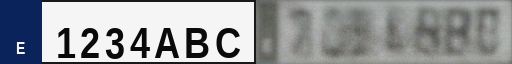

OK: finetune_pix2pix/finetune_epoch001.pt


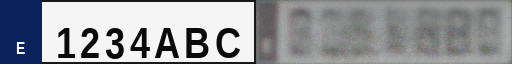

OK: finetune_pix2pix/finetune_epoch002.pt


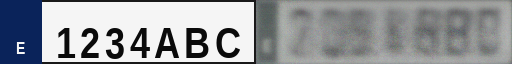

OK: finetune_pix2pix/finetune_epoch003.pt


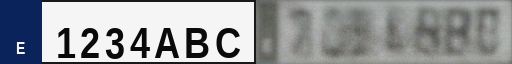

OK: finetune_pix2pix/finetune_epoch004.pt


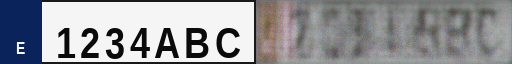

OK: finetune_pix2pix/finetune_epoch005.pt


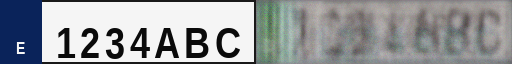

OK: finetune_pix2pix/finetune_epoch006.pt


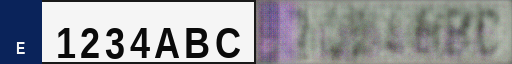

OK: finetune_pix2pix/finetune_epoch007.pt


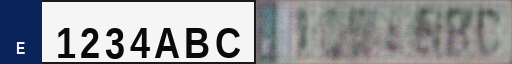

OK: finetune_pix2pix/finetune_epoch008.pt


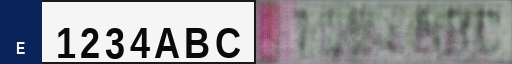

OK: finetune_pix2pix/finetune_epoch009.pt


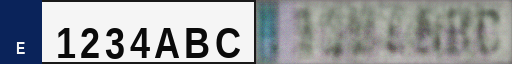

OK: finetune_pix2pix/finetune_epoch010.pt


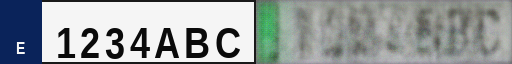

OK: finetune_pix2pix/finetune_epoch011.pt


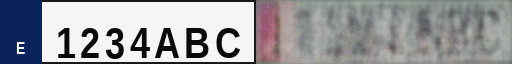

OK: finetune_pix2pix/finetune_epoch012.pt


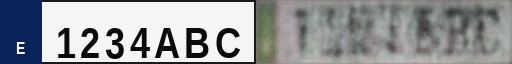

OK: pretrain_pix2pix/pretrain_best.pt


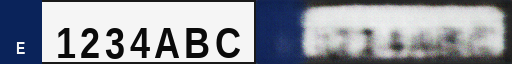

OK: pretrain_pix2pix/pretrain_epoch001.pt


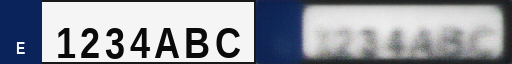

OK: pretrain_pix2pix/pretrain_epoch002.pt


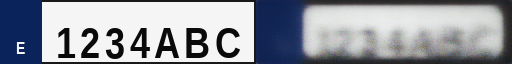

OK: pretrain_pix2pix/pretrain_epoch003.pt


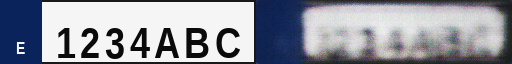

OK: pretrain_pix2pix/pretrain_epoch004.pt


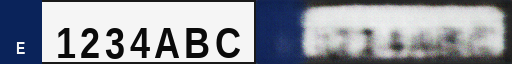

OK: pretrain_pix2pix/pretrain_epoch005.pt


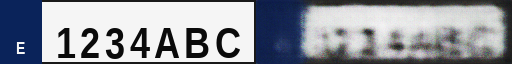

processed = 19
skipped = 0
wyniki zapisane w: /content/work/models/_abc1234_from_ckpts


In [20]:
# Verification of .pt checkpoints


import os
from pathlib import Path

import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from IPython.display import display

# device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# paths
MODELS_ROOT = Path("./work/models").resolve()
OUT_ROOT = MODELS_ROOT / "_abc1234_from_ckpts"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# parameters
TEXT = "1234ABC"
PLATE_W = 256
PLATE_H = 64
N_PER_CKPT = 5

# determinism
torch.manual_seed(123)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(123)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# PIL -> tensor [-1, 1]
def pil_to_tensor(pil_img: Image.Image) -> torch.Tensor:
    arr = np.array(pil_img.convert("RGB")).astype("float32") / 255.0
    t = torch.from_numpy(arr).permute(2, 0, 1)
    return t * 2.0 - 1.0


# tensor [-1, 1] -> PIL
def tensor_to_pil(t: torch.Tensor) -> Image.Image:
    t = t.detach().cpu().clamp(-1, 1)
    t = (t + 1.0) * 0.5
    arr = (t.permute(1, 2, 0).numpy() * 255.0).astype(np.uint8)
    return Image.fromarray(arr)


# combine clean and fake images
def make_pair(clean_img: Image.Image, fake_img: Image.Image) -> Image.Image:
    w, h = clean_img.size
    out = Image.new("RGB", (w * 2, h))
    out.paste(clean_img, (0, 0))
    out.paste(fake_img, (w, 0))
    return out


# save PNG
def save_png(path: Path, img: Image.Image):
    img.save(path, format="PNG")


# extract generator weights
def extract_g_state(ckpt):
    if not isinstance(ckpt, dict):
        return None
    if "G_state" in ckpt and isinstance(ckpt["G_state"], dict):
        return ckpt["G_state"]
    return None


# search for checkpoints
ckpts = []
if not MODELS_ROOT.exists():
    raise RuntimeError("Brak folderu models")

for root, dirs, files in os.walk(MODELS_ROOT):
    for fn in files:
        if fn.endswith(".pt"):
            ckpts.append(Path(root) / fn)

ckpts = sorted(ckpts)
if len(ckpts) == 0:
    raise RuntimeError("Brak plików .pt")

print("Liczba checkpointów:", len(ckpts))


# prepare clean input
clean_pil = render_clean_spanish_plate(TEXT, w=PLATE_W, h=PLATE_H)
clean_tensor = pil_to_tensor(clean_pil).unsqueeze(0).to(DEVICE)


# run a single checkpoint
@torch.no_grad()
def run_one_ckpt(ckpt_path: Path):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    g_state = extract_g_state(ckpt)
    if g_state is None:
        return False, None

    G = GeneratorUNet().to(DEVICE)

    try:
        G.load_state_dict(g_state, strict=True)
    except Exception:
        G.load_state_dict(g_state, strict=False)

    G.eval()

    rel = ckpt_path.relative_to(MODELS_ROOT)
    out_dir = OUT_ROOT / rel.parent / ckpt_path.stem
    out_dir.mkdir(parents=True, exist_ok=True)

    save_png(out_dir / "clean.png", clean_pil)

    preview = None
    i = 0
    while i < N_PER_CKPT:
        fake = G(clean_tensor)
        fake_pil = tensor_to_pil(fake[0])

        save_png(out_dir / f"run{i:02d}_fake.png", fake_pil)
        pair = make_pair(clean_pil, fake_pil)
        save_png(out_dir / f"run{i:02d}_pair.png", pair)

        if i == 0:
            preview = pair
        i += 1

    return True, preview


# checkpoint loop
processed = 0
skipped = 0

for p in ckpts:
    ok, preview = run_one_ckpt(p)
    if ok:
        processed += 1
        print("OK:", p.relative_to(MODELS_ROOT))
        if preview is not None:
            display(preview)
    else:
        skipped += 1
        print("SKIP:", p.relative_to(MODELS_ROOT))

print("processed =", processed)
print("skipped =", skipped)
print("wyniki zapisane w:", OUT_ROOT)
